In [1]:
!pip install rasterio matplotlib

   ---------------------------------------- 0.0/25.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/25.4 MB ? eta -:--:--
    --------------------------------------- 0.5/25.4 MB 1.3 MB/s eta 0:00:20
   - -------------------------------------- 0.8/25.4 MB 1.4 MB/s eta 0:00:18
   - -------------------------------------- 0.8/25.4 MB 1.4 MB/s eta 0:00:18
   - -------------------------------------- 1.0/25.4 MB 1.3 MB/s eta 0:00:20
   -- ------------------------------------- 1.3/25.4 MB 1.1 MB/s eta 0:00:22
   -- ------------------------------------- 1.3/25.4 MB 1.1 MB/s eta 0:00:22
   -- ------------------------------------- 1.6/25.4 MB 953.2 kB/s eta 0:00:26
   -- ------------------------------------- 1.6/25.4 MB 953.2 kB/s eta 0:00:26
   -- ------------------------------------- 1.8/25.4 MB 898.8 kB/s eta 0:00:27
   --- ------------------------------------ 2.1/25.4 MB 917.5 kB/s eta 0:00:26
   --- ------------------------------------ 2.4/25.4 MB 938.7 kB/s eta 0:00:25
   

In [3]:
!pip install rasterio tqdm

In [1]:
!pip install glob

ERROR: Could not find a version that satisfies the requirement glob (from versions: none)
ERROR: No matching distribution found for glob


In [3]:
!pip install scikit-learn

  Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


You should consider upgrading via the 'c:\users\rochan\desktop\coding\glacial_lale_detection_bah-2025\glacial-lake-detection-bah-2025-venv\scripts\python.exe -m pip install --upgrade pip' command.


# Displaying Input stack,lake mask and the bands in it

LISS3_11_input_stack.tif: 8 bands


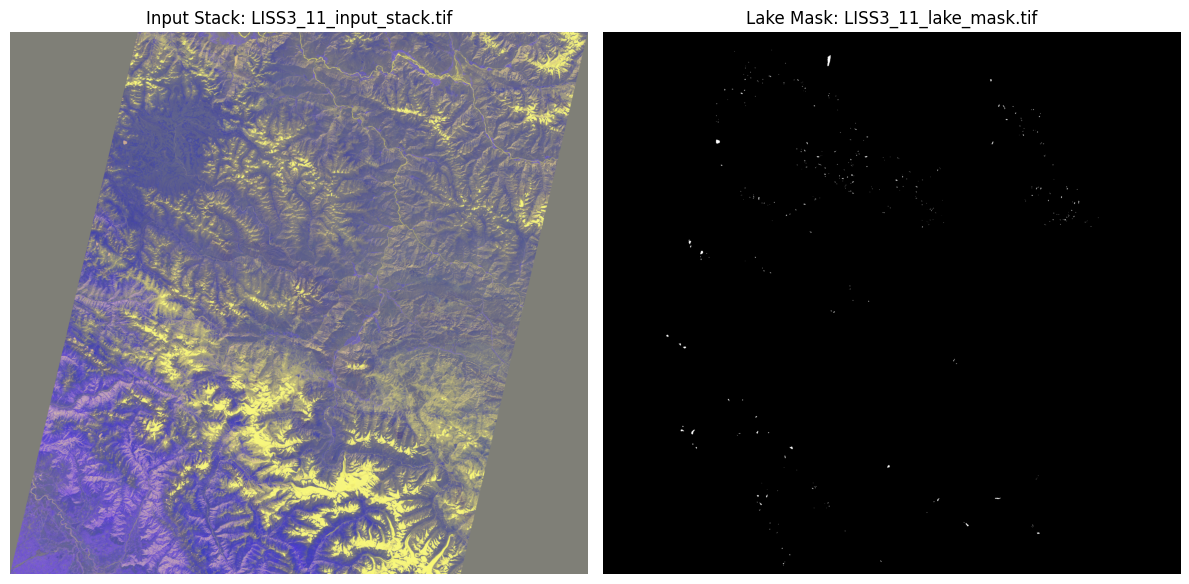

LISS3_12_input_stack.tif: 8 bands


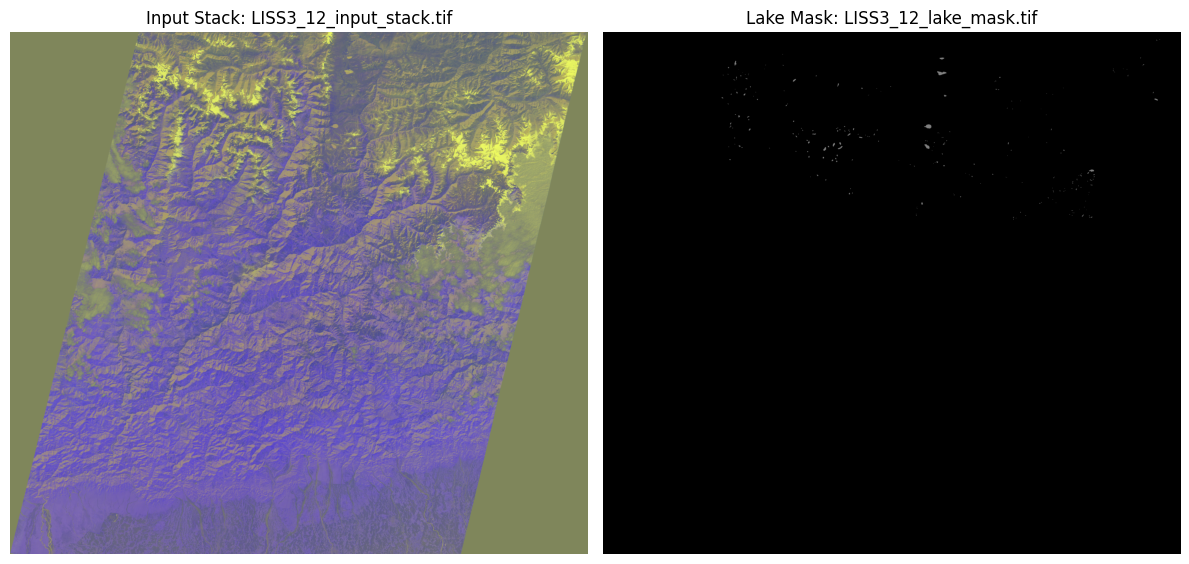

LISS3_15_input_stack.tif: 8 bands


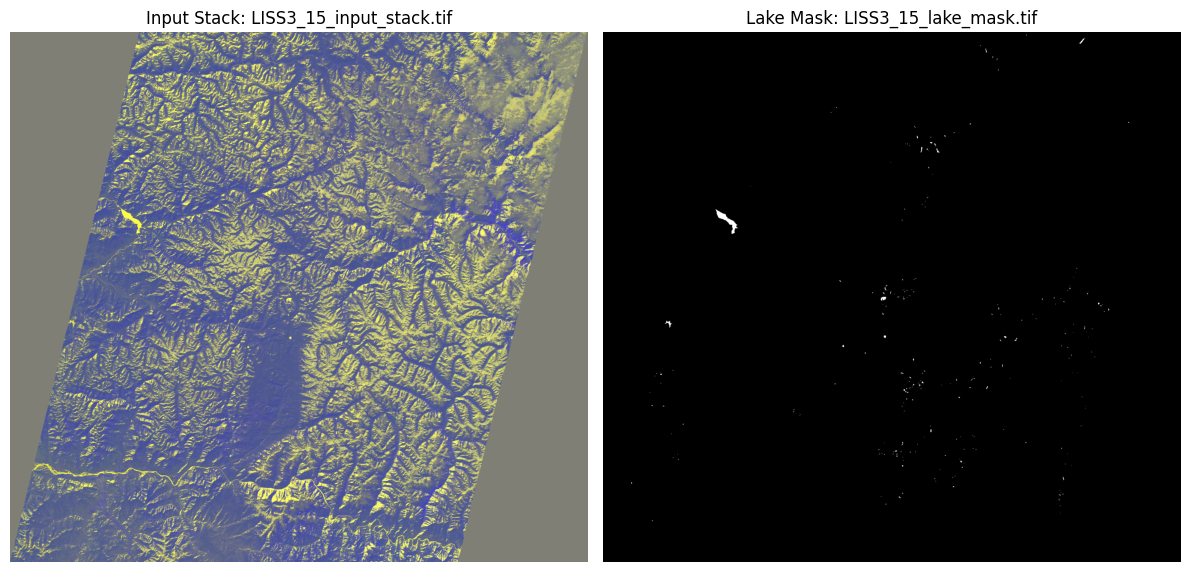

LISS3_1_input_stack.tif: 8 bands


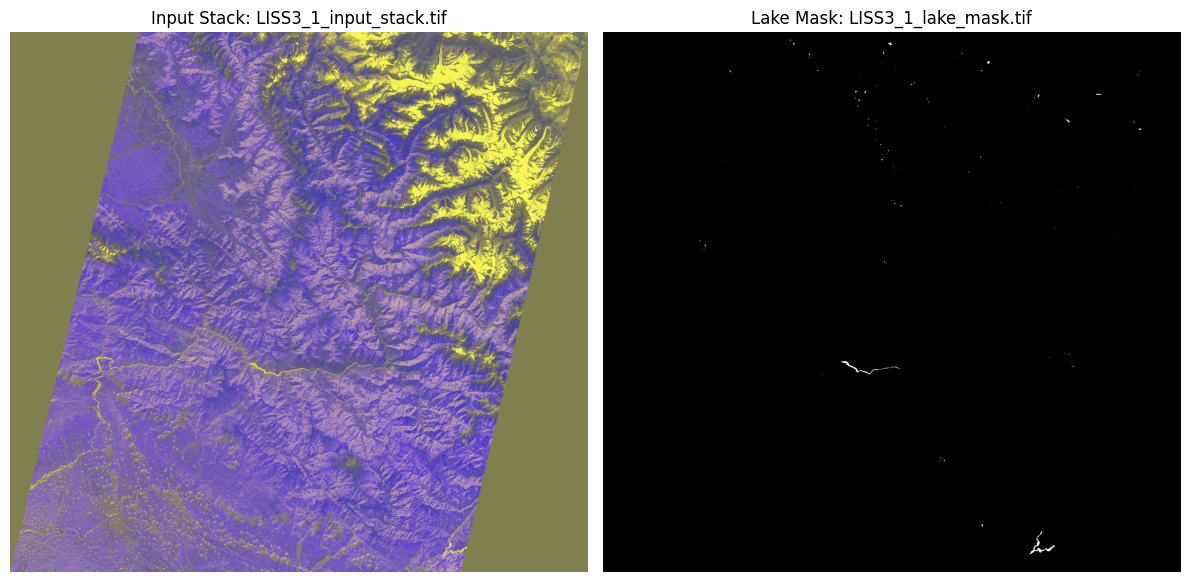

LISS3_2_input_stack.tif: 8 bands


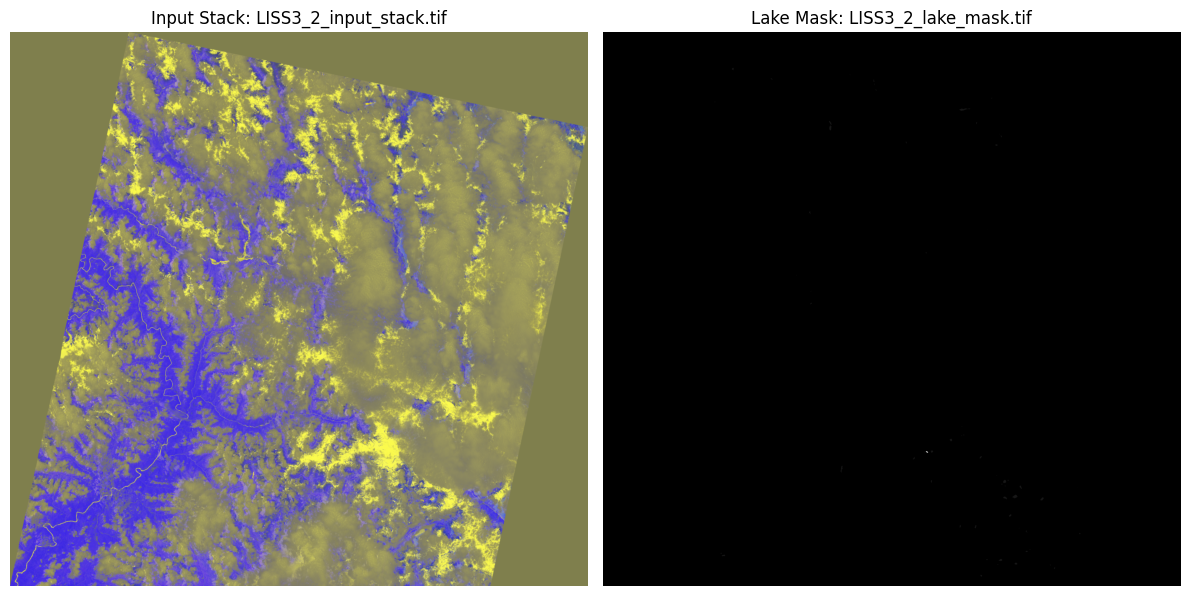

LISS3_3_input_stack.tif: 8 bands


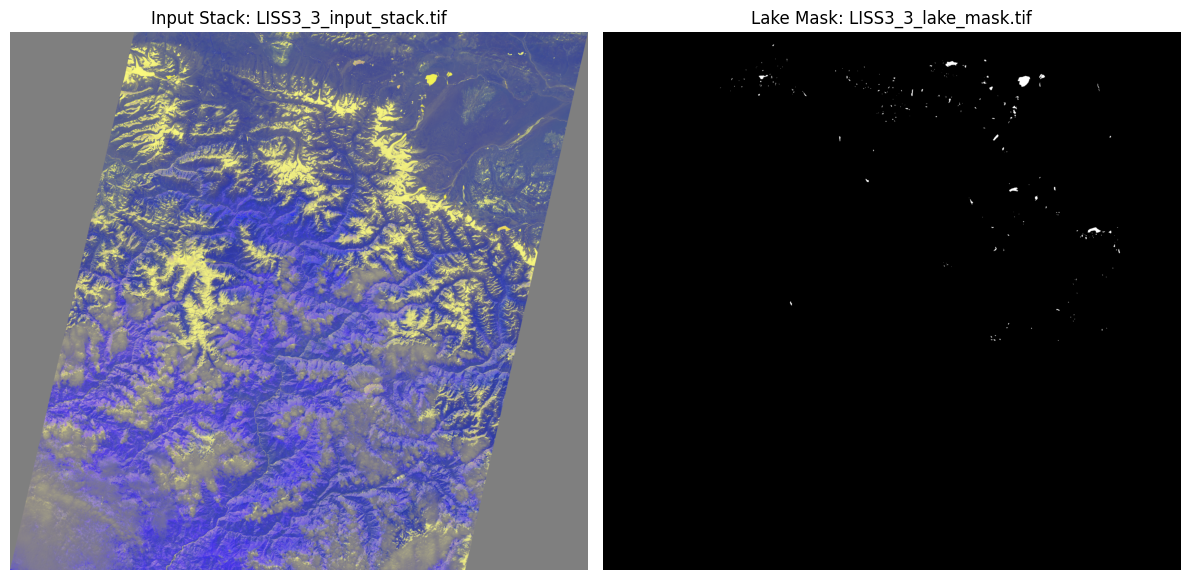

LISS3_5_input_stack.tif: 8 bands
Error processing LISS3_5: C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\LISS3_5_lake_mask.tif: No such file or directory
LISS3_6_input_stack.tif: 8 bands


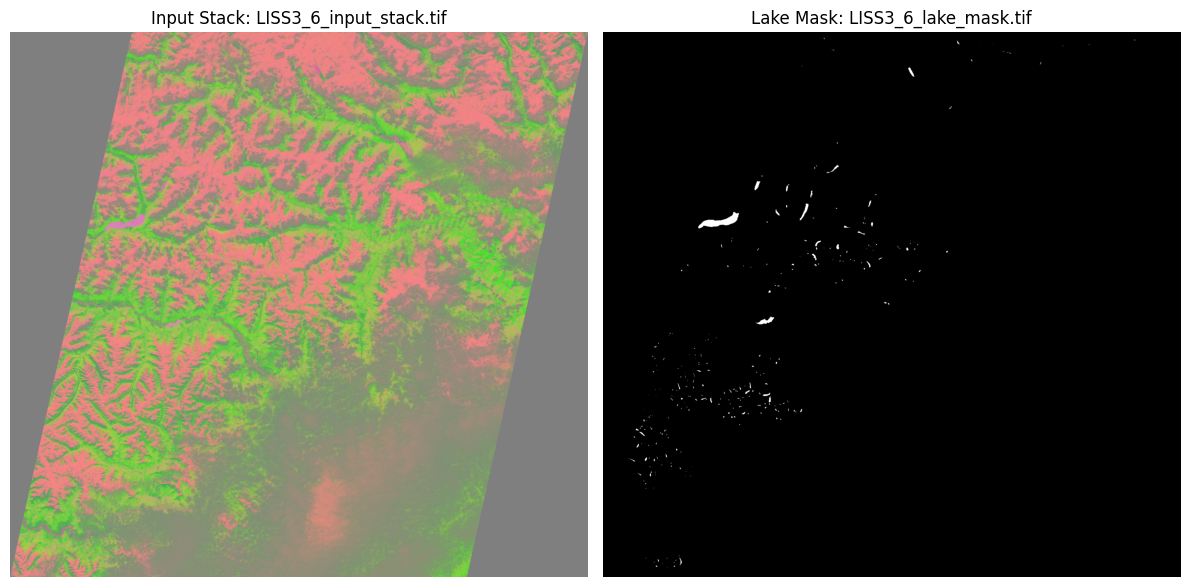

LISS3_7_input_stack.tif: 8 bands


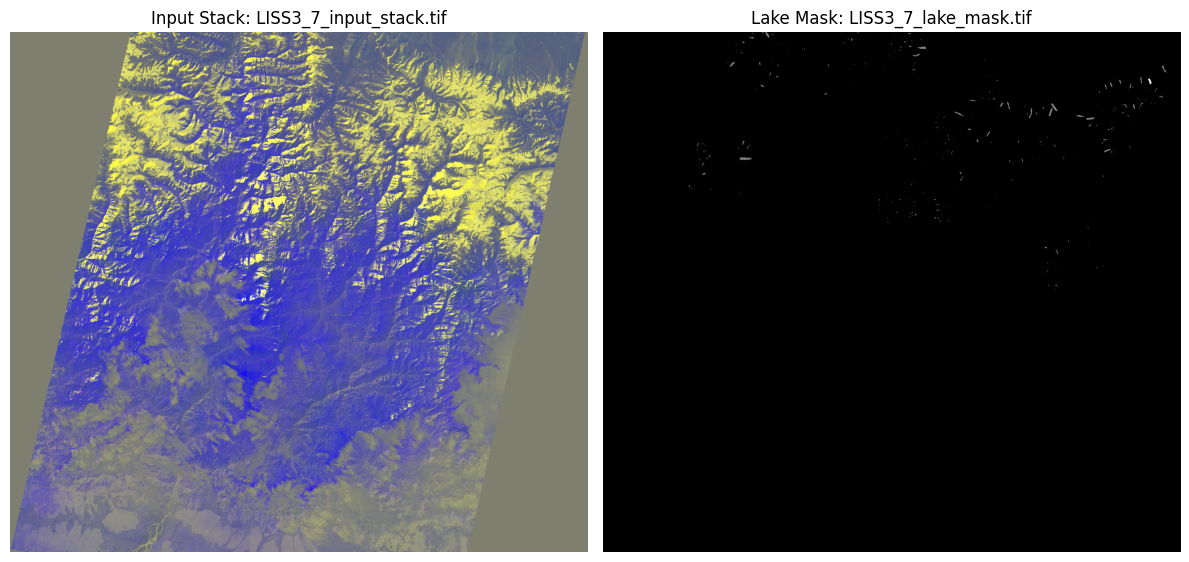

LISS3_9_input_stack.tif: 8 bands


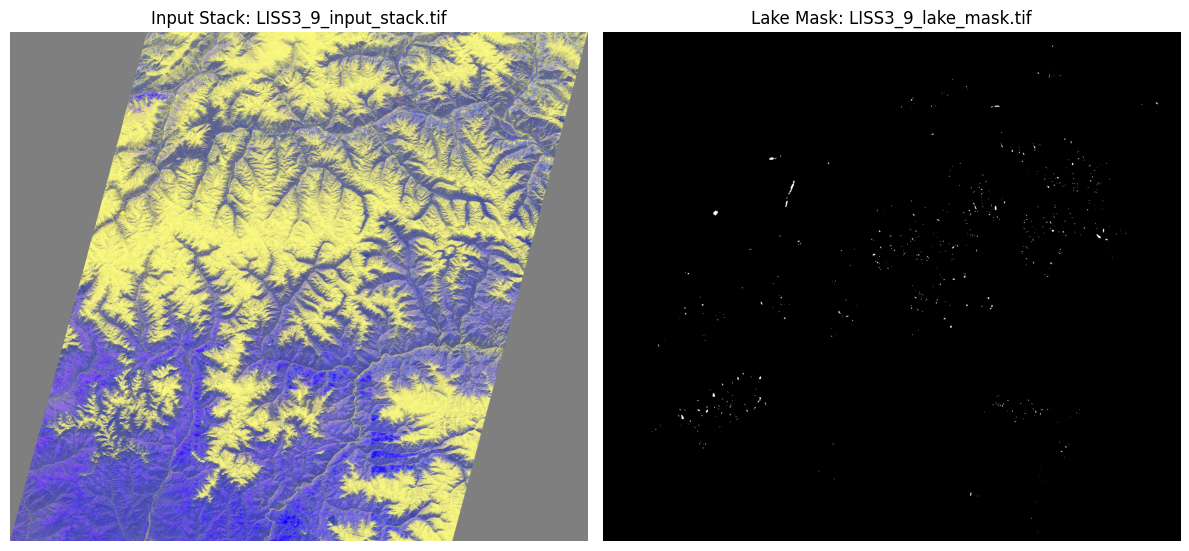

In [2]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- Define the root directories ---
input_stack_dir = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack"
lake_mask_dir = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask"

# --- Utility function to normalize band for display ---
def normalize(band):
    band_min, band_max = band.min(), band.max()
    return (band - band_min) / (band_max - band_min + 1e-6)  # prevent division by zero

# --- Loop through all input_stack files ---
for filename in os.listdir(input_stack_dir):
    if filename.endswith("_input_stack.tif"):
        base_name = filename.replace("_input_stack.tif", "")
        
        input_path = os.path.join(input_stack_dir, filename)
        mask_path = os.path.join(lake_mask_dir, f"{base_name}_lake_mask.tif")

        try:
            # Read input stack
            with rasterio.open(input_path) as src_input:
                num_bands = src_input.count
                print(f"{filename}: {num_bands} bands")

                # Read and normalize RGB bands
                rgb_bands = src_input.read([1, 2, 3])  # Adjust if your actual RGB bands differ
                normalized_rgb = np.dstack([
                    normalize(rgb_bands[0]),
                    normalize(rgb_bands[1]),
                    normalize(rgb_bands[2])
                ])

            # Read lake mask
            with rasterio.open(mask_path) as src_mask:
                lake_mask = src_mask.read(1)

            # Plot
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
            ax1.imshow(normalized_rgb)
            ax1.set_title(f"Input Stack: {filename}")
            ax1.axis('off')

            ax2.imshow(lake_mask, cmap='gray')
            ax2.set_title(f"Lake Mask: {base_name}_lake_mask.tif")
            ax2.axis('off')

            plt.tight_layout()
            plt.show()

        except FileNotFoundError:
            print(f"Lake mask not found for: {base_name}")
        except Exception as e:
            print(f"Error processing {base_name}: {e}")


###  This script will read your large input_stack and lake_mask files, cut them into 256x256 pixel chunks, and save themin the specified folders.

In [9]:
import os
import rasterio
from rasterio.warp import reproject, Resampling
from itertools import product
from tqdm import tqdm

def tile_raster(input_path, output_dir, output_prefix, patch_size=256):
    """
    Cuts a large raster into smaller tiles and saves them.
    """
    chunk_id = 1
    with rasterio.open(input_path) as src:
        width, height = src.width, src.height
        offsets = product(range(0, width, patch_size), range(0, height, patch_size))
        total_chunks = (width // patch_size + (1 if width % patch_size else 0)) * \
                       (height // patch_size + (1 if height % patch_size else 0))

        for col_off, row_off in tqdm(offsets, total=total_chunks, desc=f"Tiling {os.path.basename(input_path)}"):
            window = rasterio.windows.Window(col_off=col_off, row_off=row_off, width=patch_size, height=patch_size)
            chunk_data = src.read(window=window)

            if chunk_data.shape[1] == 0 or chunk_data.shape[2] == 0:
                continue

            profile = src.profile
            profile.update({
                'height': chunk_data.shape[1],
                'width': chunk_data.shape[2],
                'transform': src.window_transform(window)
            })

            output_filepath = os.path.join(output_dir, f"{output_prefix}_chunk_{chunk_id}.tif")
            with rasterio.open(output_filepath, 'w', **profile) as dst:
                dst.write(chunk_data)
            chunk_id += 1
    return chunk_id - 1

if __name__ == '__main__':
    # --- 1. Define Main Directories ---
    input_stack_dir = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack"
    lake_mask_dir = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask"

    # --- 2. Define Output Directories ---
    lake_mask_reprojected_dir = os.path.join(lake_mask_dir, "reprojected_aligned")
    input_stack_chunks_dir = os.path.join(input_stack_dir, "Chunks")
    lake_mask_chunks_dir = os.path.join(lake_mask_dir, "Chunks")

    os.makedirs(lake_mask_reprojected_dir, exist_ok=True)
    os.makedirs(input_stack_chunks_dir, exist_ok=True)
    os.makedirs(lake_mask_chunks_dir, exist_ok=True)

    print("✅ Starting reprojection and tiling process...\n")

    # --- 3. Main Loop ---
    for stack_filename in os.listdir(input_stack_dir):
        if not stack_filename.endswith("_input_stack.tif"):
            continue

        base_name = stack_filename.replace("_input_stack.tif", "")
        print(f"--- Processing pair: {base_name} ---")

        stack_path = os.path.join(input_stack_dir, stack_filename)
        mask_path_tif = os.path.join(lake_mask_dir, f"{base_name}_lake_mask.tif")
        mask_path_tiff = os.path.join(lake_mask_dir, f"{base_name}_lake_mask.tiff")

        original_mask_path = None
        if os.path.exists(mask_path_tif):
            original_mask_path = mask_path_tif
        elif os.path.exists(mask_path_tiff):
            original_mask_path = mask_path_tiff
        
        if original_mask_path is None:
            print(f"⚠️  Warning: Mask for {base_name} not found. Skipping.\n")
            continue
        
        print(f"Found mask file: {os.path.basename(original_mask_path)}")
        reprojected_mask_path = os.path.join(lake_mask_reprojected_dir, f"{base_name}_mask_aligned.tif")

        # --- STEP A: REPROJECTION ---
        print(f"Reprojecting mask to match {stack_filename}...")
        with rasterio.open(stack_path) as match_src:
            dst_profile = match_src.profile.copy()
            dst_profile.update({'count': 1, 'dtype': 'uint8'}) # Ensure mask is single band

        with rasterio.open(original_mask_path) as mask_src:
            with rasterio.open(reprojected_mask_path, 'w', **dst_profile) as dst:
                reproject(
                    source=rasterio.band(mask_src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=mask_src.transform,
                    src_crs=mask_src.crs,
                    dst_transform=dst_profile['transform'],
                    dst_crs=dst_profile['crs'],
                    dst_nodata=0, # Assuming 0 is the nodata value for your mask
                    resampling=Resampling.nearest
                )
        print("Reprojection complete.")
        
        # --- NEW: VERIFICATION STEP ---
        print("Verifying properties of created rasters...")
        is_match = True
        with rasterio.open(stack_path) as stack_ds, \
             rasterio.open(reprojected_mask_path) as mask_ds:

            if stack_ds.width != mask_ds.width or stack_ds.height != mask_ds.height:
                print("🔥 CRITICAL ERROR: Dimensions do not match AFTER reprojection!")
                print(f"  Input Stack: Width={stack_ds.width}, Height={stack_ds.height}")
                print(f"  Aligned Mask: Width={mask_ds.width}, Height={mask_ds.height}")
                is_match = False

            if stack_ds.crs != mask_ds.crs:
                print("🔥 CRITICAL ERROR: CRS do not match AFTER reprojection!")
                is_match = False

        if not is_match:
            print("Skipping tiling for this pair due to verification failure.\n")
            continue
        print("Verification successful.")
        # --- END OF VERIFICATION STEP ---

        # --- STEP B: TILING ---
        print("Tiling reprojected mask and input stack...")
        num_input_chunks = tile_raster(stack_path, input_stack_chunks_dir, f"{base_name}_input_stack")
        num_mask_chunks = tile_raster(reprojected_mask_path, lake_mask_chunks_dir, f"{base_name}_lake_mask")

        if num_input_chunks != num_mask_chunks:
            print(f"🔥 CRITICAL WARNING: Mismatch in chunk count for {base_name}!")
        else:
            print(f"Successfully created {num_input_chunks} aligned chunk pairs for {base_name}.\n")

    print("\n✅ All operations complete!")

✅ Starting reprojection and tiling process...

--- Processing pair: LISS3_11 ---
Found mask file: LISS3_11_lake_mask.tif
Reprojecting mask to match LISS3_11_input_stack.tif...
Reprojection complete.
Verifying properties of created rasters...
Verification successful.
Tiling reprojected mask and input stack...


Tiling LISS3_11_mask_aligned.tif: 100%|█████████████████████████████████████████████| 899/899 [00:04<00:00, 203.71it/s]


Successfully created 899 aligned chunk pairs for LISS3_11.

--- Processing pair: LISS3_12 ---
Found mask file: LISS3_12_lake_mask.tif
Reprojecting mask to match LISS3_12_input_stack.tif...
Reprojection complete.
Verifying properties of created rasters...
Verification successful.
Tiling reprojected mask and input stack...


Tiling LISS3_12_mask_aligned.tif: 100%|█████████████████████████████████████████████| 868/868 [00:04<00:00, 211.78it/s]


Successfully created 868 aligned chunk pairs for LISS3_12.

--- Processing pair: LISS3_15 ---
Found mask file: LISS3_15_lake_mask.tif
Reprojecting mask to match LISS3_15_input_stack.tif...
Reprojection complete.
Verifying properties of created rasters...
Verification successful.
Tiling reprojected mask and input stack...


...

Successfully created 870 aligned chunk pairs for LISS3_6.

--- Processing pair: LISS3_7 ---
Found mask file: LISS3_7_lake_mask.tif
Reprojecting mask to match LISS3_7_input_stack.tif...
Reprojection complete.
Verifying properties of created rasters...
Verification successful.
Tiling reprojected mask and input stack...


Tiling LISS3_7_mask_aligned.tif: 100%|██████████████████████████████████████████████| 810/810 [00:03<00:00, 214.62it/s]


Successfully created 810 aligned chunk pairs for LISS3_7.

--- Processing pair: LISS3_9 ---
Found mask file: LISS3_9_lake_mask.tif
Reprojecting mask to match LISS3_9_input_stack.tif...
Reprojection complete.
Verifying properties of created rasters...
Verification successful.
Tiling reprojected mask and input stack...


Tiling LISS3_9_mask_aligned.tif: 100%|██████████████████████████████████████████████| 896/896 [00:04<00:00, 210.87it/s]

Successfully created 896 aligned chunk pairs for LISS3_9.


✅ All operations complete!


### Scaning all the chunks, classifying them into positive(with lakes) and negative(no lakes) and then copy a 1:1 ratio of positive-to-negative chunks into new "filtered_chunks" directories.

In [10]:
import os
import glob
import shutil
import random
import rasterio
import numpy as np
from tqdm import tqdm

def filter_and_copy_chunks(mask_chunks_dir, image_chunks_dir,
                           filtered_mask_dir, filtered_image_dir,
                           ratio_neg_to_pos=1.0):
    """
    Filters chunks based on the presence of features in the mask and copies
    them to new directories based on a specified ratio.

    Args:
        mask_chunks_dir (str): Directory containing all the mask chunks.
        image_chunks_dir (str): Directory containing all the image chunks.
        filtered_mask_dir (str): Output directory for filtered mask chunks.
        filtered_image_dir (str): Output directory for filtered image chunks.
        ratio_neg_to_pos (float): The desired ratio of negative to positive samples.
                                  For example, 1.0 means a 1:1 ratio.
    """
    # --- 1. Identify Positive and Negative Samples ---
    print("Scanning mask chunks to identify positive and negative samples...")
    
    positive_samples = []
    negative_samples = []

    # Get a list of all mask files from the source directory
    mask_files = glob.glob(os.path.join(mask_chunks_dir, "*.tif"))

    if not mask_files:
        print(f"🔥 Error: No .tif files found in the mask directory: {mask_chunks_dir}")
        return

    for mask_path in tqdm(mask_files, desc="Scanning masks"):
        try:
            with rasterio.open(mask_path) as src:
                mask_data = src.read(1)
                # If any pixel is greater than 0, it's a positive sample (contains a lake)
                if np.any(mask_data > 0):
                    positive_samples.append(mask_path)
                else:
                    negative_samples.append(mask_path)
        except rasterio.errors.RasterioIOError as e:
            print(f"\nCould not read file {mask_path}. Skipping. Error: {e}")


    num_pos = len(positive_samples)
    num_neg = len(negative_samples)
    print(f"\nFound {num_pos} positive chunks (with lakes).")
    print(f"Found {num_neg} negative chunks (without lakes).")

    if num_pos == 0:
        print("\nNo positive samples found. Cannot proceed with filtering. Exiting.")
        return

    # --- 2. Select Files to Copy Based on Ratio ---
    # We will select a number of negative samples equal to (number of positives * ratio)
    # We use min() to ensure we don't try to select more negatives than we actually have.
    num_neg_to_select = min(num_neg, int(num_pos * ratio_neg_to_pos))
    
    print(f"\nSelecting all {num_pos} positive chunks.")
    print(f"Randomly selecting {num_neg_to_select} negative chunks for a ~1:{ratio_neg_to_pos} ratio.")

    # Randomly select the negative samples without replacement
    selected_negatives = random.sample(negative_samples, num_neg_to_select)
    
    # Combine the lists of files to be copied
    files_to_copy = positive_samples + selected_negatives
    random.shuffle(files_to_copy) # Shuffle to mix positive/negative for any later steps


    # --- 3. Copy Selected Files to Filtered Directories ---
    print(f"\nCopying {len(files_to_copy)} total chunks to filtered directories...")
    copied_count = 0
    for mask_source_path in tqdm(files_to_copy, desc="Copying files"):
        mask_filename = os.path.basename(mask_source_path)
        
        # This logic assumes a consistent naming pattern like:
        # Mask:  LISS3_11_lake_mask_chunk_1.tif
        # Image: LISS3_11_input_stack_chunk_1.tif
        image_filename = mask_filename.replace('lake_mask', 'input_stack')
        image_source_path = os.path.join(image_chunks_dir, image_filename)

        # Define destination paths
        mask_dest_path = os.path.join(filtered_mask_dir, mask_filename)
        image_dest_path = os.path.join(filtered_image_dir, image_filename)

        # Check if the corresponding image chunk exists before copying
        if os.path.exists(image_source_path):
            shutil.copy2(mask_source_path, mask_dest_path)
            shutil.copy2(image_source_path, image_dest_path)
            copied_count += 1
        else:
            print(f"\nWarning: Could not find matching image chunk for {mask_filename}. Skipping pair.")
            
    print("\n--- Filtering Summary ---")
    print(f"Positive chunks copied: {num_pos}")
    print(f"Negative chunks copied: {num_neg_to_select}")
    print(f"Total chunks in filtered directories: {copied_count}")


if __name__ == '__main__':
    # --- Configuration ---
    # Input directories containing ALL the chunks from the previous step
    IMG_CHUNKS_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\Chunks"
    MSK_CHUNKS_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\Chunks"

    # Output directories for the new, filtered, and balanced dataset
    FILTERED_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\filtered_chunks"
    # Corrected the path to use 'lake_mask' for consistency
    FILTERED_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\filtered_chunks"

    # Create output directories if they don't exist to prevent errors
    os.makedirs(FILTERED_IMG_DIR, exist_ok=True)
    os.makedirs(FILTERED_MSK_DIR, exist_ok=True)
    
    # --- Run the Process ---
    # Set the ratio to 1.0 for a 1:1 balance of negative to positive samples
    filter_and_copy_chunks(
        mask_chunks_dir=MSK_CHUNKS_DIR,
        image_chunks_dir=IMG_CHUNKS_DIR,
        filtered_mask_dir=FILTERED_MSK_DIR,
        filtered_image_dir=FILTERED_IMG_DIR,
        ratio_neg_to_pos=1.0 
    )

    print("\n✅ Filtering and copying process complete!")

Scanning mask chunks to identify positive and negative samples...


Scanning masks: 100%|██████████████████████████████████████████████████████████████| 7790/7790 [01:41<00:00, 76.38it/s]



Found 1018 positive chunks (with lakes).
Found 6772 negative chunks (without lakes).

Selecting all 1018 positive chunks.
Randomly selecting 1018 negative chunks for a ~1:1.0 ratio.

Copying 2036 total chunks to filtered directories...


Copying files: 100%|███████████████████████████████████████████████████████████████| 2036/2036 [00:24<00:00, 82.16it/s]


--- Filtering Summary ---
Positive chunks copied: 1018
Negative chunks copied: 1018
Total chunks in filtered directories: 2036

✅ Filtering and copying process complete!


### Splitting the data in 80:10:10 ratio for training , testing and validation

In [1]:
import os
import glob
import shutil
import numpy as np
import rasterio
from sklearn.model_selection import train_test_split
from tqdm import tqdm

def get_stratification_labels(mask_files):
    """
    Scans mask files to create a list of labels (1 for lake, 0 for no lake)
    for stratified splitting.
    """
    print("Scanning masks to create labels for stratification...")
    labels = []
    for mask_path in tqdm(mask_files, desc="Generating labels"):
        with rasterio.open(mask_path) as src:
            # Check if any pixel is non-zero
            if np.any(src.read(1)):
                labels.append(1)
            else:
                labels.append(0)
    return labels

def split_and_copy_files(image_dir, mask_dir, output_paths):
    """
    Splits files into stratified train/val/test sets and copies them
    into a predefined directory structure.
    """
    # --- 1. Create All Necessary Output Directories ---
    print("Creating destination directories...")
    for path in output_paths.values():
        os.makedirs(path, exist_ok=True)
    print("Directories created successfully.")

    # --- 2. Get File Lists and Labels for Stratification ---
    print("\nFinding all filtered mask chunks...")
    all_mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))

    if not all_mask_files:
        print(f"Error: No mask files found in {mask_dir}")
        return

    print(f"Found {len(all_mask_files)} total filtered chunks.")
    
    # Generate labels (0 or 1) for stratification
    labels = get_stratification_labels(all_mask_files)

    # --- 3. Perform Stratified Split ---
    # First, split into training (80%) and a temporary set (20%)
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        all_mask_files, labels, test_size=0.20, random_state=42, stratify=labels
    )
    
    # Split the temporary set (20%) into validation (10%) and test (10%)
    # This is a 50/50 split of the temporary set
    val_files, test_files, _, _ = train_test_split(
        temp_files, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
    )

    file_splits = {
        "Training": train_files,
        "Validation": val_files,
        "Testing": test_files
    }
    print("\nStratified dataset split determined:")
    for name, files in file_splits.items():
        print(f"  - {name} samples: {len(files)}")

    # --- 4. Define the Copying Function ---
    def copy_file_set(files, img_dest_dir, mask_dest_dir):
        """Copies a list of mask files and their corresponding images to specified folders."""
        for mask_source_path in tqdm(files, desc=f"Copying to {os.path.basename(img_dest_dir)}"):
            mask_filename = os.path.basename(mask_source_path)
            # Find the corresponding image file
            img_filename = mask_filename.replace('lake_mask', 'input_stack')
            img_source_path = os.path.join(image_dir, img_filename)

            img_dest_path = os.path.join(img_dest_dir, img_filename)
            mask_dest_path = os.path.join(mask_dest_dir, mask_filename)

            if os.path.exists(img_source_path):
                shutil.copy2(img_source_path, img_dest_path)
                shutil.copy2(mask_source_path, mask_dest_path)
            else:
                print(f"Warning: Could not find matching image for {mask_filename}")

    # --- 5. Execute the Copying Process for Each Set ---
    print("\nStarting file copy process...")
    copy_file_set(train_files, output_paths['train_img'], output_paths['train_mask'])
    copy_file_set(val_files, output_paths['val_img'], output_paths['val_mask'])
    copy_file_set(test_files, output_paths['test_img'], output_paths['test_mask'])


if __name__ == '__main__':
    # --- Configuration ---
    # Input directories with the filtered chunks from the previous step
    FILTERED_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\filtered_chunks"
    FILTERED_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\filtered_chunks"

    # Base directories for the final output
    INPUT_STACK_BASE = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack"
    LAKE_MASK_BASE = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask"

    # Define the specific output directories
    output_directory_paths = {
        'train_mask': os.path.join(LAKE_MASK_BASE, 'train'),
        'val_mask':   os.path.join(LAKE_MASK_BASE, 'validate'),
        'test_mask':  os.path.join(LAKE_MASK_BASE, 'test'),
        'train_img':  os.path.join(INPUT_STACK_BASE, 'train'),
        'val_img':    os.path.join(INPUT_STACK_BASE, 'validate'),
        'test_img':   os.path.join(INPUT_STACK_BASE, 'test')
    }

    # --- Run the Process ---
    split_and_copy_files(
        image_dir=FILTERED_IMG_DIR,
        mask_dir=FILTERED_MSK_DIR,
        output_paths=output_directory_paths
    )

    print("\n✅ Splitting and copying to specified directories is complete!")

Creating destination directories...
Directories created successfully.

Finding all filtered mask chunks...
Found 2045 total filtered chunks.
Scanning masks to create labels for stratification...


Generating labels: 100%|██████████████████████████████████████████████████████████| 2045/2045 [00:19<00:00, 105.99it/s]



Stratified dataset split determined:
  - Training samples: 1636
  - Validation samples: 204
  - Testing samples: 205

Starting file copy process...


Copying to train:  10%|██████                                                      | 165/1636 [00:00<00:09, 156.18it/s]

Copying to train:  13%|███████▉                                                    | 217/1636 [00:01<00:08, 161.25it/s]

...

Copying to train:  51%|██████████████████████████████▌                             | 832/1636 [00:05<00:04, 164.96it/s]

Copying to train:  57%|██████████████████████████████████▏                         | 931/1636 [00:05<00:04, 150.22it/s]

Copying to train:  70%|█████████████████████████████████████████▎                 | 1146/1636 [00:07<00:03, 138.73it/s]

Copying to test: 100%|██████████████████████████████████████████████████████████████| 205/205 [00:01<00:00, 147.48it/s]


✅ Splitting and copying to specified directories is complete!
